# 07. Toptan Müşteri Segmentasyonu

**Kategori:** Kümeleme  
**Gerçek veri seti:** UCI Wholesale Customers  
**Veri kaynağı:** [https://archive.ics.uci.edu/dataset/292/wholesale+customers](https://archive.ics.uci.edu/dataset/292/wholesale+customers)  
**Amaç:** Yıllık ürün grubu harcamalarına göre benzer müşteri segmentleri keşfetmek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Veriyi tanıma ve dağılımlar

In [2]:
df = pd.read_csv(DATA_DIR / "wholesale_customers.csv")
display(df.head())
print("Boyut:", df.shape, "| Eksik:", int(df.isna().sum().sum()), "| Tekrar:", df.duplicated().sum())
display(df.describe().T.round(1))

Boyut: (440, 8) | Eksik: 0 | Tekrar: 0


,channel,region,fresh,milk,grocery,frozen,detergents_paper,delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


,count,mean,std,min,25%,50%,75%,max
channel,440.0,1.3,0.5,1.0,1.0,1.0,2.0,2.0
region,440.0,2.5,0.8,1.0,2.0,3.0,3.0,3.0
fresh,440.0,12000.3,12647.3,3.0,3127.8,8504.0,16933.8,112151.0
milk,440.0,5796.3,7380.4,55.0,1533.0,3627.0,7190.2,73498.0
grocery,440.0,7951.3,9503.2,3.0,2153.0,4755.5,10655.8,92780.0
frozen,440.0,3071.9,4854.7,25.0,742.2,1526.0,3554.2,60869.0
detergents_paper,440.0,2881.5,4767.9,3.0,256.8,816.5,3922.0,40827.0
delicassen,440.0,1524.9,2820.1,3.0,408.2,965.5,1820.2,47943.0


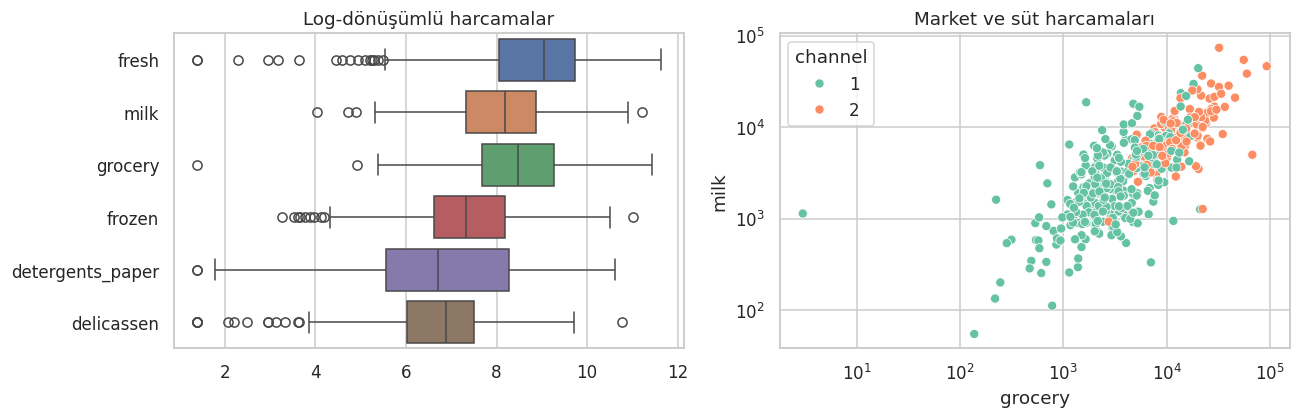

In [3]:
spend_cols = ["fresh", "milk", "grocery", "frozen", "detergents_paper", "delicassen"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=np.log1p(df[spend_cols]), orient="h", ax=axes[0])
axes[0].set(title="Log-dönüşümlü harcamalar")
sns.scatterplot(data=df, x="grocery", y="milk", hue="channel", palette="Set2", ax=axes[1])
axes[1].set(xscale="log", yscale="log", title="Market ve süt harcamaları")
plt.tight_layout(); plt.show()

## 2. Küme sayısını veriden seçme

,k,inertia,silhouette
0,2,1844.064,0.290
1,3,1553.340,0.259
2,4,1386.863,0.188
3,5,1266.149,0.192
4,6,1174.516,0.193


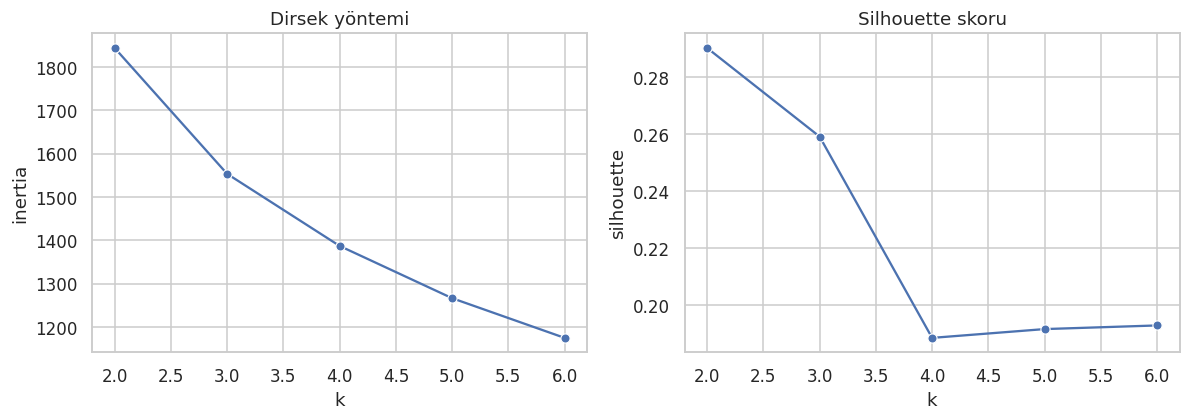

In [4]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

X = df[spend_cols]
prep = make_pipeline(FunctionTransformer(np.log1p), StandardScaler())
X_scaled = prep.fit_transform(X)
k_values = range(2, 7)
models = {k: KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE).fit(X_scaled)
          for k in k_values}
evaluation = pd.DataFrame({
    "k": list(k_values),
    "inertia": [models[k].inertia_ for k in k_values],
    "silhouette": [silhouette_score(X_scaled, models[k].labels_) for k in k_values],
})
display(evaluation.round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.lineplot(data=evaluation, x="k", y="inertia", marker="o", ax=axes[0])
sns.lineplot(data=evaluation, x="k", y="silhouette", marker="o", ax=axes[1])
axes[0].set(title="Dirsek yöntemi"); axes[1].set(title="Silhouette skoru")
plt.tight_layout(); plt.show()

,fresh,milk,grocery,frozen,detergents_paper,delicassen
cluster,,,,,,
0,10348.0,1871.0,2406.0,2225.0,328.0,750.0
1,5406.0,7690.0,11527.0,1062.0,4495.0,1388.0


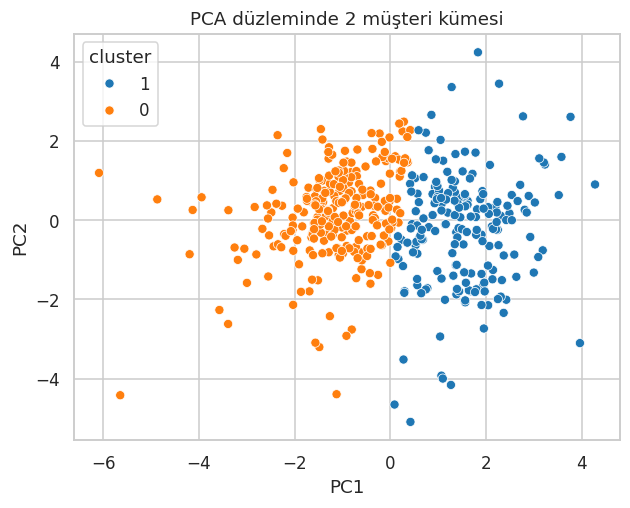

In [5]:
best_k = int(evaluation.loc[evaluation.silhouette.idxmax(), "k"])
best_model = models[best_k]
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
plot_df = pd.DataFrame(coords, columns=["PC1", "PC2"]).assign(cluster=best_model.labels_.astype(str))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", palette="tab10")
plt.title(f"PCA düzleminde {best_k} müşteri kümesi"); plt.show()
profile = df[spend_cols].assign(cluster=best_model.labels_).groupby("cluster").median().round(0)
display(profile)
joblib.dump({"preprocessor": prep, "model": best_model, "best_k": best_k,
             "features": spend_cols, "evaluation": evaluation},
            MODEL_DIR / "07_toptan_musteri_kumeleme.joblib")
json.dump({"best_k": best_k, "silhouette": float(evaluation.silhouette.max())},
          open(RESULT_DIR / "07_toptan_musteri.json", "w"), indent=2)

## Sonuç

Harcamalar çok sağa çarpık olduğu için `log1p` ve standardizasyon uygulandı. Küme sayısı önceden
varsayılmadı; 2–6 aralığında silhouette ile seçildi. Küme profilleri medyan harcamalarla
yorumlandığından uç değerlerin etkisi azaltıldı.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **K-Means ile müşteri segmentasyonu** biçimindedir.
Bu notebookta **gerçek harcamalar, çarpıklık dönüşümü, veriyle k seçimi, PCA görseli ve segment profilleri** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).